# Import Libraries

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Load Dataset

We load the salary dataset.

In [3]:
df=pd.read_csv("salary.csv")
print(df.head())

    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


## Remove Unnecessary Columns

We remove:
- Age
- Gender

Because they are not required for prediction.

In [4]:
df.drop(["Age", "Gender"], axis=1, inplace=True)
df.head()

,Education Level,Job Title,Years of Experience,Salary
0,Bachelor's,Software Engineer,5.0,90000.0
1,Master's,Data Analyst,3.0,65000.0
2,PhD,Senior Manager,15.0,150000.0
3,Bachelor's,Sales Associate,7.0,60000.0
4,Master's,Director,20.0,200000.0


## Check Dataset Information

We check:
- Data types
- Null values

In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education Level      6701 non-null   object 
 1   Job Title            6702 non-null   object 
 2   Years of Experience  6701 non-null   float64
 3   Salary               6699 non-null   float64
dtypes: float64(2), object(2)
memory usage: 209.6+ KB


Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [6]:
df.dropna(inplace=True)

## Separate Features and Target

X = Input features  
y = Salary

In [7]:
X=df.drop("Salary",axis=1)
y=df["Salary"]

## Convert Categorical Columns

We use pd.get_dummies() for:
- Education Level
- Job Title

This is called One-Hot Encoding.

In [8]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,Years of Experience,Education Level_Bachelor's Degree,Education Level_High School,Education Level_Master's,Education Level_Master's Degree,Education Level_PhD,Education Level_phD,Job Title_Accountant,Job Title_Administrative Assistant,Job Title_Back end Developer,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,5.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,3.0,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,15.0,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,7.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,20.0,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Train-Test Split

We divide the dataset into:

- 80% Training Data
- 20% Testing Data

Training data → Model learns
Testing data → Model performance check

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

## Feature Scaling

ANN works better when all input values
are on similar scale.

We use StandardScaler.

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Build ANN Model

We create a Sequential neural network
with:

- 2 Hidden Layers
- ReLU activation
- 1 Output neuron (for regression)

In [11]:
model=Sequential()
model.add(Dense(64,activation='relu',input_shape=(X_train.shape[1],)))
model.add(Dense(32,activation='relu'))
model.add(Dense(1))


C:\Users\Tirupati\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile Model

We define:

- Optimizer
- Loss function
- Evaluation metric

In [12]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

## Train Model

We train the ANN using training data.

In [14]:
history = model.fit(X_train,y_train,epochs=150,batch_size=8,validation_split=0.2)

Epoch 1/150
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 446910592.0000 - mae: 15968.8311 - val_loss: 580262080.0000 - val_mae: 16838.4844
Epoch 2/150
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 443603904.0000 - mae: 15848.2803 - val_loss: 576202688.0000 - val_mae: 16786.0352
Epoch 3/150
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 441209056.0000 - mae: 15817.3887 - val_loss: 572964160.0000 - val_mae: 16724.5215
Epoch 4/150
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 438802016.0000 - mae: 15791.3799 - val_loss: 569863040.0000 - val_mae: 16611.5273
Epoch 5/150
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 437443168.0000 - mae: 15728.6631 - val_loss: 569884608.0000 - val_mae: 16548.7539
Epoch 6/150
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 436111648.0000 - mae: 15695.2324 - val_loss: 565495168.0000 - val_mae: 16504.6582
Epoch 7/150
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 434307744.0000 - mae: 15637.7070 - val_loss: 563040384.0000 - val_mae: 16501.8320

## Model Evaluation Metrics

We calculate:
- MAE (Mean Absolute Error)
- MSE (Mean Squared Error)
- R2 Score

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)
print("Mean Salary:", y.mean())

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE: 12792.782012301772
MSE: 352810001.8607553
R2 Score: 0.8762703685702653
Mean Salary: 115329.25306061511


## Make Predictions

We use model.predict()

to estimate salary.

In [17]:
predictions = model.predict(X_test)
print(predictions[:5])

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
[[132847.1  ]
 [ 87550.38 ]
 [ 99559.15 ]
 [ 62526.957]
 [ 68172.73 ]]


## Graph 1: Model Loss (MSE)

This graph shows:
- Training Loss
- Validation Loss

It helps to detect:
- Overfitting
- Underfitting
- Learning behavior

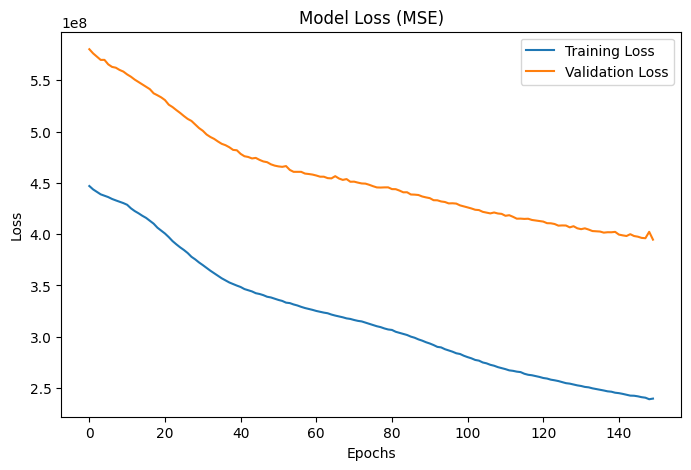

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss (MSE)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("model loss MSE", dpi=300, bbox_inches='tight')
plt.show()

## Graph 2: Model MAE

This graph shows:
- Training MAE
- Validation MAE

It represents real-world average prediction error.

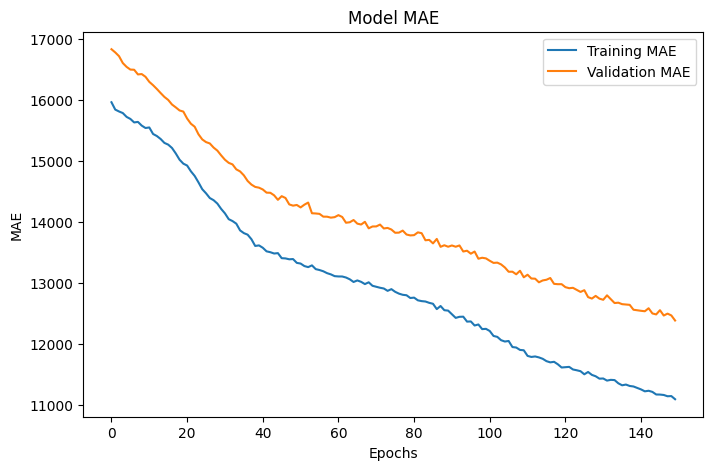

In [28]:
plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.title("Model MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.savefig("model MAE", dpi=300, bbox_inches='tight')

plt.show()

## Graph 3: Actual vs Predicted

This graph compares:
- Real Salary (Actual)
- Model Prediction (Predicted)

It shows how close predictions are to real values.

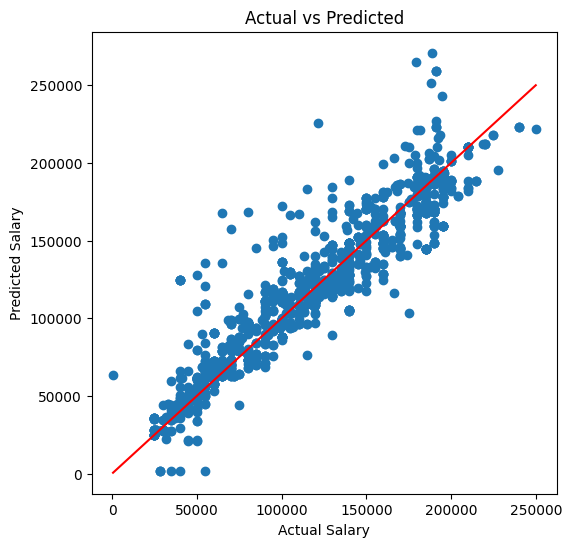

In [29]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.savefig("Actual vs Predicted", dpi=300, bbox_inches='tight')
plt.show()

## Save Trained Model and Preprocessing Files

Before deploying the model using Streamlit, 
we need to save the trained ANN model and preprocessing objects.

We will save:

- Trained ANN model (.h5 file)
- Scaler object (.pkl file)
- Feature column names (.pkl file)

These files ensure that:
- The same scaling is applied during prediction
- Column order remains consistent
- The trained model can be loaded without retraining

In [36]:
import joblib

joblib.dump(scaler, "scaler.pkl")


joblib.dump(X.columns, "columns.pkl")

model.save("salary_model.keras")